In [28]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

### Understanding the basics of the Heston stochastic volatility model!

We are uncertain of what a random variable's actual value is until we observe it. Even though the outcome is uncertain, random variables follow patterns we can describe mathematically, like the random variable's:

 * Distribution
 * Mean ($\mu$)
 * Variance ($\sigma^2$)
 * Standard Deviation ($\sigma$)

These are basic tools for understanding random variables.

#### Mean
The mean is the average or center of the random variable, given by the expected value of the random variable X, or $\mathbb{E}[X]$.
#### Variance and Standard Deviation
The variance measures how spread out the variable is around its mean, given by $\mathbb{E}[(X-\mathbb{E}[X])^2]$. The standard deviation, $\sigma$, is just the square root of variance. Smaller $\sigma$ values stay close to the mean, and values fluctuate more if $\sigma$ is larger.
#### Normal Distribution
The normal distribution is a type of probability density function, or (PDF) that tells us what values the random variable can take and how likely those values are. The normal distribution is a bell-shaped curve, where we define the mean and standard deviation. Assigning a random variable to a normal distribution looks like this: 
$X \sim \mathcal{N}(\mu, \sigma^2)$

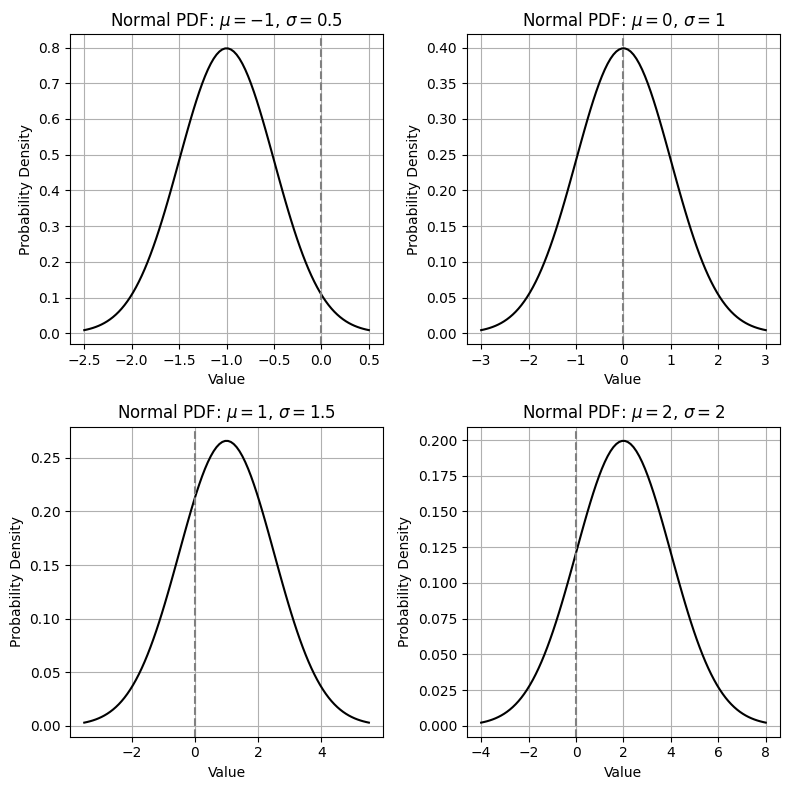

In [30]:
mu_values = [-1, 0, 1, 2]
sigma_values = [0.5, 1, 1.5, 2]

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
x = np.linspace(mu_values[0] - 3*sigma_values[0], mu_values[0] + 3*sigma_values[0], 100)
y = sp.stats.norm.pdf(x, mu_values[0], sigma_values[0])
plt.plot(x, y, color='k')
plt.axvline(x=0, color='gray', linestyle='--')
plt.title(r"Normal PDF: $\mu=-1$, $\sigma=0.5$")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.grid(True)

plt.subplot(2, 2, 2)
x = np.linspace(mu_values[1] - 3*sigma_values[1], mu_values[1] + 3*sigma_values[1], 100)
y = sp.stats.norm.pdf(x, mu_values[1], sigma_values[1])
plt.plot(x, y, color='k')
plt.axvline(x=0, color='gray', linestyle='--')
plt.title(r"Normal PDF: $\mu=0$, $\sigma=1$")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.grid(True)

plt.subplot(2, 2, 3)
x = np.linspace(mu_values[2] - 3*sigma_values[2], mu_values[2] + 3*sigma_values[2], 100)
y = sp.stats.norm.pdf(x, mu_values[2], sigma_values[2])
plt.plot(x, y, color='k')
plt.axvline(x=0, color='gray', linestyle='--')
plt.title(r"Normal PDF: $\mu=1$, $\sigma=1.5$")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.grid(True)

plt.subplot(2, 2, 4)
x = np.linspace(mu_values[3] - 3*sigma_values[3], mu_values[3] + 3*sigma_values[3], 100)
y = sp.stats.norm.pdf(x, mu_values[3], sigma_values[3])
plt.plot(x, y, color='k')
plt.axvline(x=0, color='gray', linestyle='--')
plt.title(r"Normal PDF: $\mu=2$, $\sigma=2$")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.grid(True)

plt.tight_layout()
plt.show()

### The bridge from probability to stochastic processes is the random walk!

A simple **discrete** random walk is given by $X_{n+1} = X_{n} + \zeta_{n+1}$, where each step $\zeta_{n+1}$ is random, with an equal probability to be $+1$ or $-1$.

If we take smaller and smaller time steps, and scale the jump sizes properly, the discrete random walk approaches a continuous-time process. This process is called **Brownian motion.**

#### Brownian motion

Starting with $W_{0} = 0$, we make independent, normal increments. For a time interval s, $X_{s} = W_{t+s} - W_{t} \sim \mathcal{N}(0,s)$. Since $W_{t} \sim \mathcal{N}(0,t)$, at a fixed time t, Brownian motion is normally distributed with mean 0 and variance $t$. This means the variance of the process gets larger as time goes on. Note that $dW_{t} \sim \mathcal{N}(0, dt)$. If we simulate paths and look at their endpoints, we can match to the theoretical normal probability density function. 

#### Central Limit Theorem (CLT) Visualized
The Central Limit Theorem states that as sample size $n$ increases, the distribution of sample means approaches a normal distribution, regardless of the original distribution shape, provided it has finite variance. In the graph below, the normal distribution with mean 0 and standard deviation $\sqrt{T}$ is visualized, where T is the time interval of Brownian motion. 10,000 Brownian walks are realized and their endpoints are placed into a histogram, whose density follows the shape of the normal distribution.

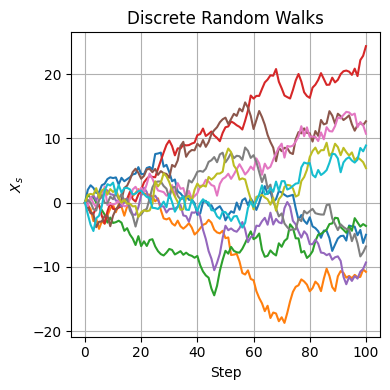

In [31]:
steps = 100
paths = 10
plt.figure(figsize=(4,4))
for i in range(paths):
    step = np.random.normal(0, 1, steps)
    path = np.concatenate(([0], np.cumsum(step)))
    plt.plot(path)
plt.title("Discrete Random Walks")
plt.xlabel("Step")
plt.ylabel("$X_{s}$")
plt.grid(True)
plt.tight_layout()
plt.show()

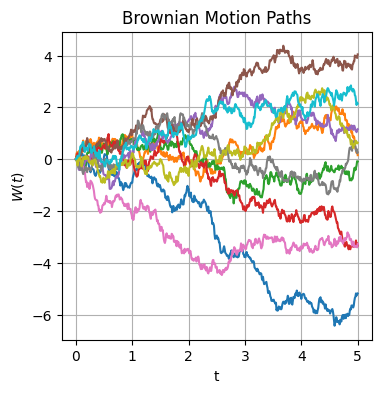

In [32]:
T = 5
steps = 500
dt = T / steps
t = np.linspace(0, T, steps + 1)
paths = 10

plt.figure(figsize=(4,4))
for i in range(paths):
    dW = np.sqrt(dt) * np.random.randn(steps)
    W = np.concatenate(([0], np.cumsum(dW)))
    plt.plot(t, W)

plt.title("Brownian Motion Paths")
plt.xlabel("t")
plt.ylabel("$W(t)$")
plt.grid(True)
plt.show()

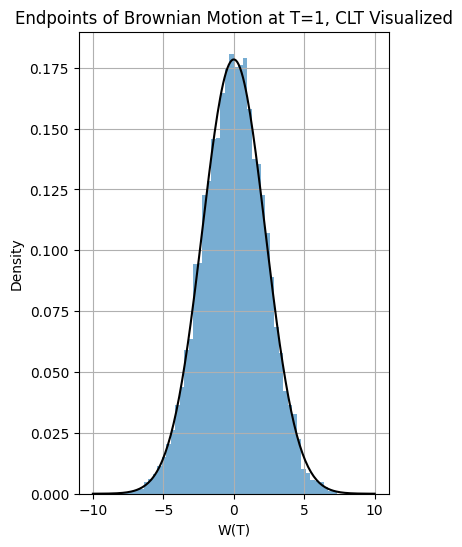

In [33]:
T = 5
steps = 500
dt = T / steps
paths = 10000

W_T = np.zeros(paths)

for i in range(paths):
    dW = np.sqrt(dt) * np.random.randn(steps)
    W = np.sum(dW)
    W_T[i] = W

x = np.linspace(-10, 10, 200)
y = sp.stats.norm.pdf(x, 0, np.sqrt(T))

plt.figure(figsize=(4,6))
plt.hist(W_T, bins=50, density=True, alpha=0.6)
plt.plot(x, y, color='k')
plt.title("Endpoints of Brownian Motion at T=1, CLT Visualized")
plt.xlabel("W(T)")
plt.ylabel("Density")
plt.grid(True)
plt.show()

### From random walk to Stochastic Differential Equation (SDE)!
In a discrete random walk, we have something like $X_{n+1} = X_{n} + \text{random step.}$
As mentioned earlier, in Brownian motion, the random step over a small time interval $\Delta t$ is $\Delta W \sim \mathcal{N}(0, \Delta t)$, so a discrete stochastic update might look like $X_{n+1} = X_{n} + \mu \Delta t + \sigma \Delta W_{n}$. Rearranging for the change in $X_{t}$, we get the continuous time version of this equation, an **SDE** with a drift term and noise term. $$dX_{t} = \mu dt + \sigma dW_{t}$$

Note that $\Delta X \sim \mathcal{N}(\mu \Delta t, \sigma^2\Delta t)$. So drift contributes an order $\Delta t$ and noise an order $\sqrt{\Delta t}$.

We will explore if this SDE also follows the CLT, using the Euler-Murayama simulation method.

### Why do financial experts use SDE's over ODE's?

An ODE looks like $dX_{t} = f(X_{t}, t)dt$, where everything is deterministic. An SDE has the form, $dX_{t} = f(X_{t}, t)dt + g(X_{t}, t)dW_{t}$ which adds a noise term. This noise models the random fluctuations of asset prices. We will soon see that the noise term represents volatility, and in the Heston model, volatility is its own SDE.

### Simulating an SDE with the Euler-Murayama method

This is basically the Euler method for SDE's. $$X_{n+1} = X_{n} + \mu(X_{n}, t_{n})\Delta t + \sigma(X_{n}, t_{n})\Delta W_{n}$$

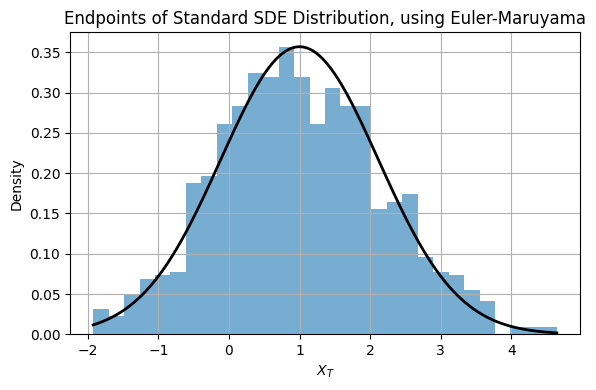

In [34]:
T = 5
steps = 500
dt = T / steps
paths = 1000

mu = 0.2
sigma = 0.5

X_T = np.zeros(paths)

for i in range(paths):
    X = 0.0
    for n in range(steps):
        dW = np.sqrt(dt) * np.random.randn()
        X = X + mu * dt + sigma * dW
    X_T[i] = X

x = np.linspace(min(X_T), max(X_T), 300)
y = sp.stats.norm.pdf(x, mu*T, sigma*np.sqrt(T))

plt.figure(figsize=(6,4))
plt.hist(X_T, bins=30, density=True, alpha=0.6)
plt.plot(x, y, linewidth=2, color='black')
plt.xlabel(r"$X_T$")
plt.ylabel("Density")
plt.title("Endpoints of Standard SDE Distribution, using Euler-Maruyama")
plt.grid(True)
plt.tight_layout()
plt.show()

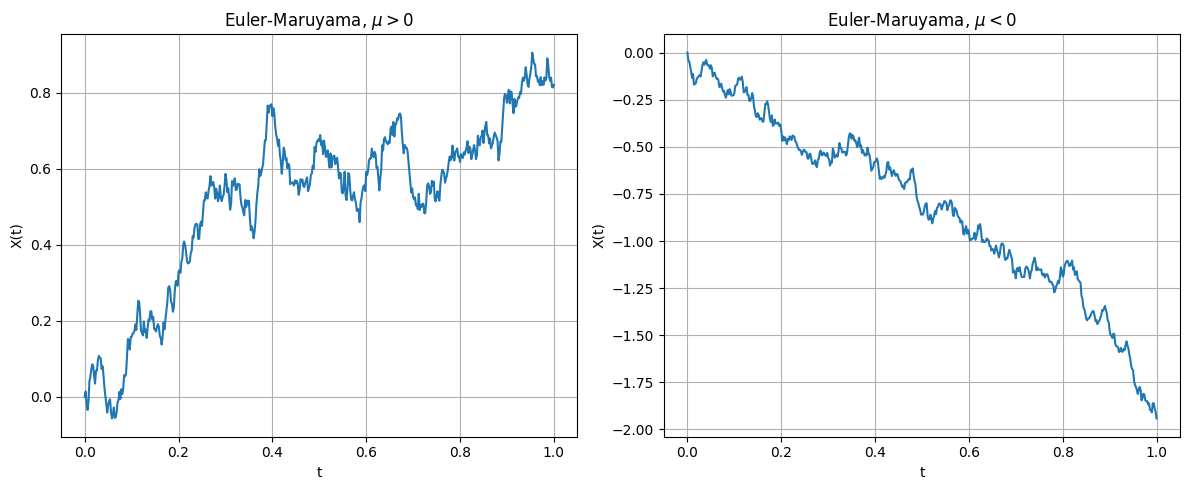

In [43]:
T = 1
steps = 500
dt = T / steps
t = np.linspace(0, T, steps + 1)

sigma = 0.5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mu = 1
X = np.zeros(steps + 1)
X[0] = 0

for n in range(steps):
    dW = np.sqrt(dt) * np.random.randn()
    X[n+1] = X[n] + mu * dt + sigma * dW

axes[0].plot(t, X)
axes[0].set_title(r"Euler-Maruyama, $\mu > 0$")
axes[0].set_xlabel("t")
axes[0].set_ylabel("X(t)")
axes[0].grid(True)

mu = -1
X = np.zeros(steps + 1)
X[0] = 0

for n in range(steps):
    dW = np.sqrt(dt) * np.random.randn()
    X[n+1] = X[n] + mu * dt + sigma * dW

axes[1].plot(t, X)
axes[1].set_title(r"Euler-Maruyama, $\mu < 0$")
axes[1].set_xlabel("t")
axes[1].set_ylabel("X(t)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Geometric Brownian Motion (GBM)

We have built up our SDE from Brownian motion. But we have the possibility to go into the negative, and we have additive increments with a fixed scale. This is not ideal for asset prices, which should stay positive. It is also more natural for asset prices to **move in percentages** rather than fixed amounts. By making the drift and the noise proportional to the current value, we arrive at **Geometric Brownian Motion (GBM).** $$dS_{t} = \mu S_{t}dt + \sigma S_{t}dW_{t}$$
Here, $S_{t}$ is the asset prices, $\mu$ is the drift, $\sigma$ is the volatility, and $dW_{t}$ is Brownian motion. The first term gives average proportional growth, and the second term gives random fluctuations whose size scales with the price itself. 

#### Simulating GBM with Euler-Murayama
We simply use the same form as before, with an extra $S_{n}$ term. $$S_{n+1} = S_{n} + \mu S_{n} \Delta t + \sigma S_{n} \Delta W_{n}$$ 
So for each step, the new price is the old price plus a determinsitic change and a random shock, both scaled by the current price. The famous **Black-Scholes equation for option pricing** is derived from assuming a stock price follows GBM!

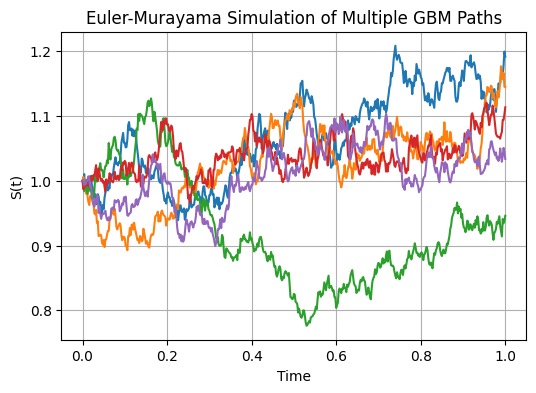

In [87]:
T = 1
steps = 500
dt = T / steps
t = np.linspace(0, T, steps + 1)

mu = 0.05
sigma = 0.2

plt.figure(figsize=(6,4))

for j in range(5):
    S = np.zeros(steps + 1)
    S[0] = 1.0
    
    for n in range(steps):
        dW = np.sqrt(dt) * np.random.randn()
        S[n+1] = S[n] + mu * S[n] * dt + sigma * S[n] * dW
    
    plt.plot(t, S)

plt.title("Euler-Murayama Simulation of Multiple GBM Paths")
plt.xlabel("Time")
plt.ylabel("S(t)")
plt.grid(True)
plt.show()

### Log returns from GBM

For GBM, the price changes multiplicatively, so it is natural to look at the log price. If we define $X_{t} = \log S_{t}$, then a log return over a time interval is $X_{t} - X_{0} = \log (\frac{S_{t}}{S_{0}})$. This means that even though $S_{t}$ is not normally distributed, the log price is normal. 

The fundamental reason the log price is normal is that the change in log price, $X_{t} - X_{0}$ is assumed to be the sum of a large number of small, independent, identically distributed (IID) random shocks. According to the Central Limit Theorem (CLT), the sum of a large number of independent random variables converges to a normal distribution.

#### Using Itô's Lemma

Let $f(S) = \log S$, then $f'(S) = \frac{1}{S}$, and $f''(S)=-\frac{1}{S^2}$. Itô's lemma says $$df(S_{t}) = f'(S_{t})dS_{t} + \frac{1}{2}f''(S_{t})(dS{t})^2$$
First we compute  $(dS_{t})^2 = \sigma^2 S_{t}^2dt$, noting that $(dW_{t})^2 = dt$. Then we substitute in for $f$. 
$$d(\log S_{t}) = \frac{1}{S_{t}}dS_{t} - \frac{1}{2}(\frac{1}{S_{t}^2})\sigma^2 S_{t}^2 dS_{t}$$ 
Which simplifies to $$d \log S_{t} = (\mu - \frac{1}{2}\sigma^2)dt + \sigma dW{t}$$

This shows that log price behaves similarly to the simpler Brownian motion additive noise model from earlier. Most importantly, this is much easier than the GBM equation.

#### The solution

Integrating the log price equation gives: $$S_{t} = S_{0} \exp[(\mu - \frac{1}{2}\sigma^2)t + \sigma W_{t}]$$ 

We can also see that the log price is normal, with $W_{t} \sim \mathcal{N}(0, t)$, we get: $$\log S_{t} \sim \mathcal{N}(\log S_{0} + (\mu - \frac{1}{2}\sigma^2)t, \sigma^2 t)$$

### Visualizing our results

We compare the theoretical normal distribution with the log price solution, as done previously, and find the CLT theorem still applying!

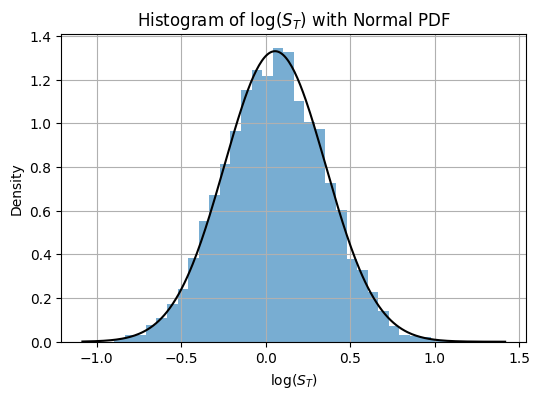

Sample mean: 0.05372485587970906
Theoretical mean: 0.05500000000000001
Sample variance: 0.09039378457667888
Theoretical variance: 0.09


In [47]:
T = 1.0
steps = 10000

S0 = 1.0
mu = 0.1
sigma = 0.3

W_T = np.sqrt(T) * np.random.randn(steps)

S_T = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * W_T)

#get log price
log_S_T = np.log(S_T)

#theoretical normal density for log(S_T)
mean = np.log(S0) + (mu - 0.5 * sigma**2) * T
std = sigma * np.sqrt(T)

x = np.linspace(min(log_S_T), max(log_S_T), 300)
pdf = sp.stats.norm.pdf(x, mean, std)

plt.figure(figsize=(6,4))
plt.hist(log_S_T, bins=40, density=True, alpha=0.6)
plt.plot(x, pdf, color='k')
plt.title(r"Histogram of $\log(S_T)$ with Normal PDF")
plt.xlabel(r"$\log(S_T)$")
plt.ylabel("Density")
plt.grid(True)
plt.show()

print("Sample mean:", np.mean(log_S_T))
print("Theoretical mean:", mean)
print("Sample variance:", np.var(log_S_T))
print("Theoretical variance:", sigma**2 * T)

### Mean Reversion and Ornstein-Uhlbeck - the last step to understand the Heston model

A process is mean reverting if it pulls back to a typical level instead of wandering away forever. Volatility has this "pulling back" feature. This ODE describes the mean reverting process, where $\kappa > 0$ is the pulling force, $\theta$ is the target level, and $X_{t}$ is the random process.

$$\frac{dX_{t}}{dt} = \kappa(\theta - X_{t})$$

If $X_{t} < \theta$ the process moves upwards, vice versa. So the sign of the process $X_{t}$ pushes $X_{t}$ back to $\theta$.

This ODE has the solution $X_{t} = \theta + (X_{0} - \theta)e^{-\kappa t}$. Rearranging for the distance from equilibrum, we get an equation that shows that the distance from $\theta$ decays exponentially. This model captures common behavior, no pure growth, no pure decay to zero, and movement to a preferred level. $$(X_{t} - \theta) = (X_{0} - \theta)e^{-\kappa t}$$

#### Ornstein-Uhlbeck process adds randomness, and is the basis for the Heston model

We now refer to $\theta$ as the "long-run mean level", $\kappa$ is the speed of reversion, and $\eta$ is the noise strength.

$$dX_{t} = \kappa(\theta - X_{t})dt + \eta dW_{t}$$

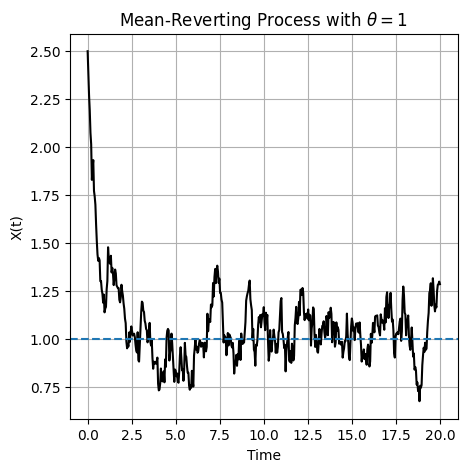

In [48]:
T = 20
n_steps = 500
dt = T / n_steps
t = np.linspace(0, T, n_steps + 1)

kappa = 2.0
theta = 1.0
sigma = 0.3

X = np.zeros(n_steps + 1)
X[0] = 2.5

for n in range(n_steps):
    dW = np.sqrt(dt) * np.random.randn()
    X[n+1] = X[n] + kappa * (theta - X[n]) * dt + sigma * dW

plt.figure(figsize=(5,5))
plt.plot(t, X, color='k')
plt.axhline(theta, linestyle='--')
plt.xlabel("Time")
plt.ylabel("X(t)")
plt.title(r"Mean-Reverting Process with $\theta=1$")
plt.grid(True)
plt.show()

### Heston Model!!!

$$dS_{t} = \mu S_{t} dt + \sqrt{V_{t}} S_{t} dW_{t}^{(1)}$$
$$dV_{t} = \kappa(\theta - V_{t})dt + \xi\sqrt{V_{t}}dW_{t}^{(2)}$$
The two Brownian motions are correlated, $dW_{t}^{(1)}, dW_{t}^{(2)} = \rho dt$

$S_{t}$ is the asset price, $V_{t}$ is the instantaneous variance, and $\sqrt{V_{t}}$ is the instantaneous volatility.
If $V_{t}$ is high, the price equation noise becomes large, so price moves more with greater volatility.
$\xi$ is the volatility of variance, often referred to as **vol of vol**. If $\xi$ is high, variance is erratic.

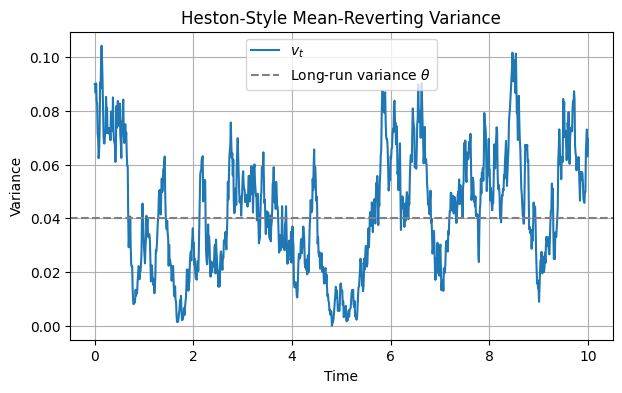

In [49]:
T = 10
n_steps = 1000
dt = T / n_steps
t = np.linspace(0, T, n_steps + 1)

kappa = 2.0
theta = 0.04
xi = 0.3
v0 = 0.09

v = np.zeros(n_steps + 1)
v[0] = v0

for n in range(n_steps):
    dW = np.sqrt(dt) * np.random.randn()
    v_now = max(v[n], 0)   # keep square root safe
    v[n+1] = v[n] + kappa * (theta - v[n]) * dt + xi * np.sqrt(v_now) * dW
    v[n+1] = max(v[n+1], 0)  # keep variance nonnegative

plt.figure(figsize=(7,4))
plt.plot(t, v, label=r"$v_t$")
plt.axhline(theta, color='gray', linestyle='--', label=r'Long-run variance $\theta$')
plt.xlabel("Time")
plt.ylabel("Variance")
plt.title("Heston-Style Mean-Reverting Variance")
plt.legend()
plt.grid(True)
plt.show()

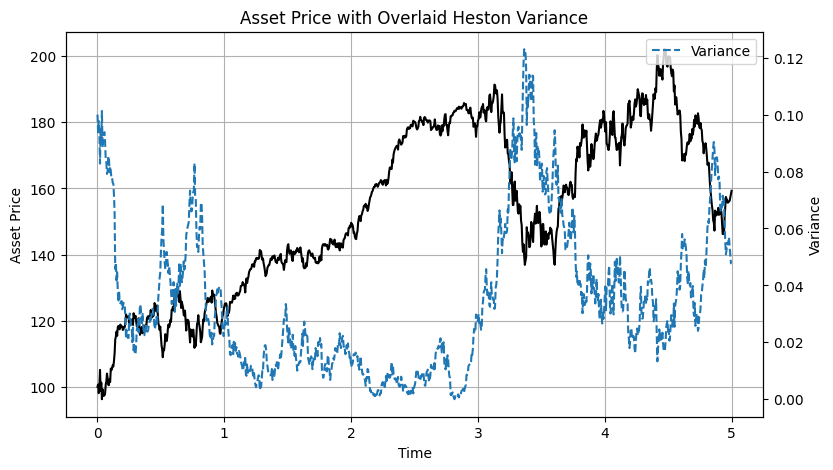

In [51]:
T = 5
n_steps = 1000
dt = T / n_steps
t = np.linspace(0, T, n_steps + 1)

mu = 0.08
kappa = 2.0
theta = 0.04
xi = 0.3

rho = -0.8

S = np.zeros(n_steps + 1)
v = np.zeros(n_steps + 1)
S[0] = 100
v[0] = 0.1

for n in range(n_steps):
    #set up the two dW_{t} terms
    Z1 = np.random.randn()
    Z2 = np.random.randn()
    
    dW1 = np.sqrt(dt) * Z1
    #this is out of my scope, but essentially ensures that the correlation
    #between dW1 and dW2 is exactly rho,
    dW2 = np.sqrt(dt) * (rho * Z1 + np.sqrt(1 - rho**2) * Z2)

    #keeping variance positive
    v_now = max(v[n], 0)
    
    #variance update
    v[n+1] = v[n] + kappa * (theta - v[n]) * dt + xi * np.sqrt(v_now) * dW2
    v[n+1] = max(v[n+1], 0)

    #price update
    S[n+1] = S[n] + mu * S[n] * dt + np.sqrt(v_now) * S[n] * dW1

#two axis plot
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(t, S, color='k', label='Asset Price')
ax1.set_xlabel("Time")
ax1.set_ylabel("Asset Price")

#share x axis
ax2 = ax1.twinx()
ax2.plot(t, v, linestyle='--', label='Variance')
ax2.set_ylabel("Variance")

plt.title("Asset Price with Overlaid Heston Variance")
ax1.grid(True)
plt.legend()
plt.show()